In [44]:
import json
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
with open("C:/Users/sanoj/local_SLM_App_with_Ollama/src/data/evaluated_result.json", "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

df.head(1)

,model_name,prompt,response,latency,tokens,tokens_per_second,memory_usage,ground_truth,correctness,relevance,conciseness,instruction_following,quality_score,judge_reason
0,llama3.2:3b,What is the capital city of France?,The capital city of France is Paris.,11.432882,7,0.61,6.64,The capital city of France is Paris.,2,2,0,2,0.75,"The answer is correct, directly answers the qu..."


In [4]:
##data analaysis  descriptive 

df.shape

(45, 14)

In [5]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['model_name', 'prompt', 'response', 'latency', 'tokens', 'tokens_per_second', 'memory_usage', 'ground_truth', 'correctness', 'relevance', 'conciseness', 'instruction_following', 'quality_score', 'judge_reason']


In [6]:
##summary of dataframee
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model_name             45 non-null     str    
 1   prompt                 45 non-null     str    
 2   response               45 non-null     str    
 3   latency                45 non-null     float64
 4   tokens                 45 non-null     int64  
 5   tokens_per_second      45 non-null     float64
 6   memory_usage           45 non-null     float64
 7   ground_truth           45 non-null     str    
 8   correctness            45 non-null     int64  
 9   relevance              45 non-null     int64  
 10  conciseness            45 non-null     int64  
 11  instruction_following  45 non-null     int64  
 12  quality_score          45 non-null     float64
 13  judge_reason           45 non-null     str    
dtypes: float64(4), int64(5), str(5)
memory usage: 40.9 KB


In [7]:
df.describe()

,latency,tokens,tokens_per_second,memory_usage,correctness,relevance,conciseness,instruction_following,quality_score
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,26.716145,70.800000,2.404444,16.135111,1.088889,1.955556,0.133333,1.266667,0.555333
std,8.569482,38.380037,1.142158,9.891438,0.763432,0.298142,0.343776,0.889331,0.230559
min,10.126994,1.000000,0.080000,1.570000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.123800,38.000000,1.770000,8.030000,1.000000,2.000000,0.000000,0.000000,0.380000
50%,29.706257,88.000000,2.870000,15.980000,1.000000,2.000000,0.000000,2.000000,0.620000
75%,33.022000,102.000000,3.110000,21.020000,2.000000,2.000000,0.000000,2.000000,0.750000
max,40.694964,108.000000,4.350000,38.060000,2.000000,2.000000,1.000000,2.000000,0.880000


In [8]:
df.dtypes

model_name                   str
prompt                       str
response                     str
latency                  float64
tokens                     int64
tokens_per_second        float64
memory_usage             float64
ground_truth                 str
correctness                int64
relevance                  int64
conciseness                int64
instruction_following      int64
quality_score            float64
judge_reason                 str
dtype: object

In [7]:
##check missing values
missing = df.isnull().sum()
missing

model_name               0
prompt                   0
response                 0
latency                  0
tokens                   0
tokens_per_second        0
memory_usage             0
ground_truth             0
correctness              0
relevance                0
conciseness              0
instruction_following    0
quality_score            0
judge_reason             0
dtype: int64

In [8]:
##check the duplicate row
df.duplicated().any()

np.False_

In [9]:
df["model_name"].value_counts()

model_name
llama3.2:3b    15
phi3:mini      15
qwen2.5:3b     15
Name: count, dtype: int64

In [11]:
df.columns

Index(['model_name', 'prompt', 'response', 'latency', 'tokens',
       'tokens_per_second', 'memory_usage', 'ground_truth', 'correctness',
       'relevance', 'conciseness', 'instruction_following', 'quality_score',
       'judge_reason'],
      dtype='str')

In [10]:
###check performance

performance_cols=[
    "latency",
    "tokens",
    "tokens_per_second",
    "memory_usage"
]


df.groupby("model_name")[performance_cols].describe()




latency                                                        \
              count       mean       std        min        25%        50%   
model_name                                                                  
llama3.2:3b    15.0  24.960367  8.164507  11.432882  19.411188  24.953458   
phi3:mini      15.0  30.753081  8.028794  12.872804  29.628572  31.822758   
qwen2.5:3b     15.0  24.434985  8.563818  10.126994  16.538753  28.066118   

                                  tokens             ... tokens_per_second  \
                   75%        max  count       mean  ...               75%   
model_name                                           ...                     
llama3.2:3b  32.537298  34.832088   15.0  71.333333  ...             3.105   
phi3:mini    35.507825  40.694964   15.0  75.000000  ...             2.950   
qwen2.5:3b   31.325751  34.118102   15.0  66.066667  ...             3.310   

                  memory_usage                                              \
              max        count       mean        std    min     25%    50%   
model_name                                                                   
llama3.2:3b  4.35         15.0   9.360667  11.474715   1.57   2.875   3.64   
phi3:mini    3.28         15.0  21.126667   7.638755  12.44  16.135  17.21   
qwen2.5:3b   3.63         15.0  17.918000   6.181177   8.03  14.200  16.52   

                            
                75%    max  
model_name                  
llama3.2:3b  10.295  38.06  
phi3:mini    23.555  35.54  
qwen2.5:3b   20.710  31.67  

[3 rows x 32 columns]

In [11]:
## ANALYZE SPEED

df.groupby("model_name")["latency"].agg(
    ["mean","median","std","min","max"]
)




,mean,median,std,min,max
model_name,,,,,
llama3.2:3b,24.960367,24.953458,8.164507,11.432882,34.832088
phi3:mini,30.753081,31.822758,8.028794,12.872804,40.694964
qwen2.5:3b,24.434985,28.066118,8.563818,10.126994,34.118102


MEAN - Average response time(qwen)
MEDIAN - Typical response time
    eg: llama - 24.9534  -typicel response time taken(25 sec)(llama)

STD - how much the latency change betwwen one to another prompt(phi)

MIN - Fastest response (qwen2.5)

MAX - Slowest response  (phi3)


Qwen2.5 showed the lower average latency (24.43 s) colsely by llama3.2

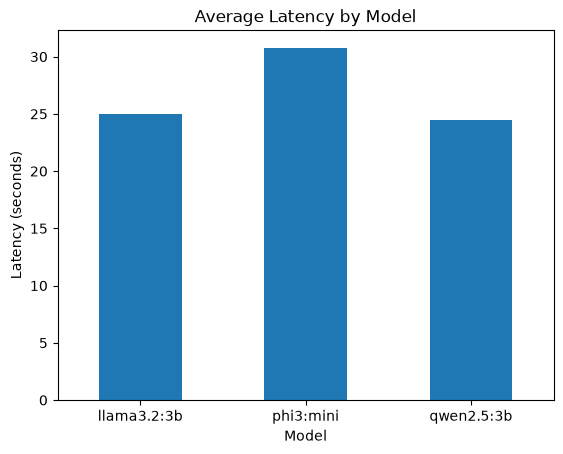

In [17]:
mean_latency = df.groupby("model_name")["latency"].mean()

mean_latency.plot(kind="bar")

plt.title("Average Latency by Model")
plt.xlabel("Model")
plt.ylabel("Latency (seconds)")
plt.xticks(rotation=0)
plt.show()

In [12]:
df["latency"].std()

np.float64(8.569482276456524)

latency::
1. MEAN
qwen 2.5 - (24.43) is fastest on average(lower response is better)
llama - (24.96) near to qwen2.5 response
phi -(30.75s) higer response(delay)
Qwen> llama > phi

2.MEDIAN
llama has lowest median latency(24.95 sec) faster than the other models

3.MIN(fastest) & MAX(slowest)
Qwen has the lowest minimum latency (10.13 seconds), while Phi has the highest maximum latency (40.69 seconds).

In [22]:
#Analyze tokens per second


summary = df.groupby("model_name")["tokens_per_second"].agg(
    ["mean", "median", "std","min","max"]

)
summary

,mean,median,std,min,max
model_name,,,,,
llama3.2:3b,2.604000,3.04,1.221228,0.08,4.35
phi3:mini,2.256000,2.50,0.996069,0.08,3.28
qwen2.5:3b,2.353333,2.99,1.243909,0.08,3.63


Mean - higher is better
llama3.2 - 2.604000
example  20 token at 2.6 token/sec    20/2.6 = 7.7 sec

MEDIAN - typical generation speed
llama3.2 is highest


STD - more consistent speed
phi3 -0.99 

MAX 
llama (4.35)


llama3.2 is the highest average token generation speed and highest median speed 

phi3:mini had the lowest std(variation ,making it consistent model,but lower average generation sppeddj)

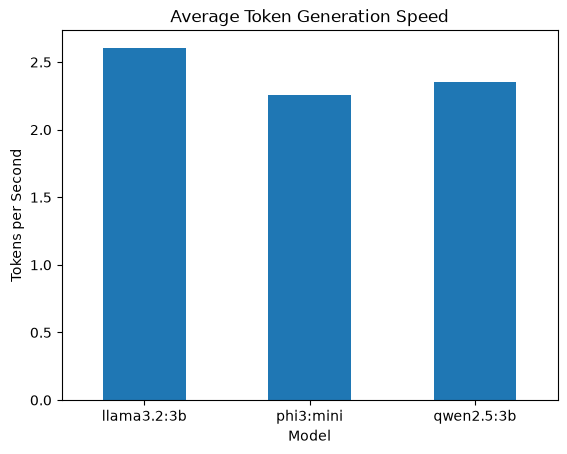

In [20]:


tps_mean = df.groupby("model_name")["tokens_per_second"].mean()

tps_mean.plot(kind="bar")

plt.title("Average Token Generation Speed")
plt.xlabel("Model")
plt.ylabel("Tokens per Second")
plt.xticks(rotation=0)
plt.show()


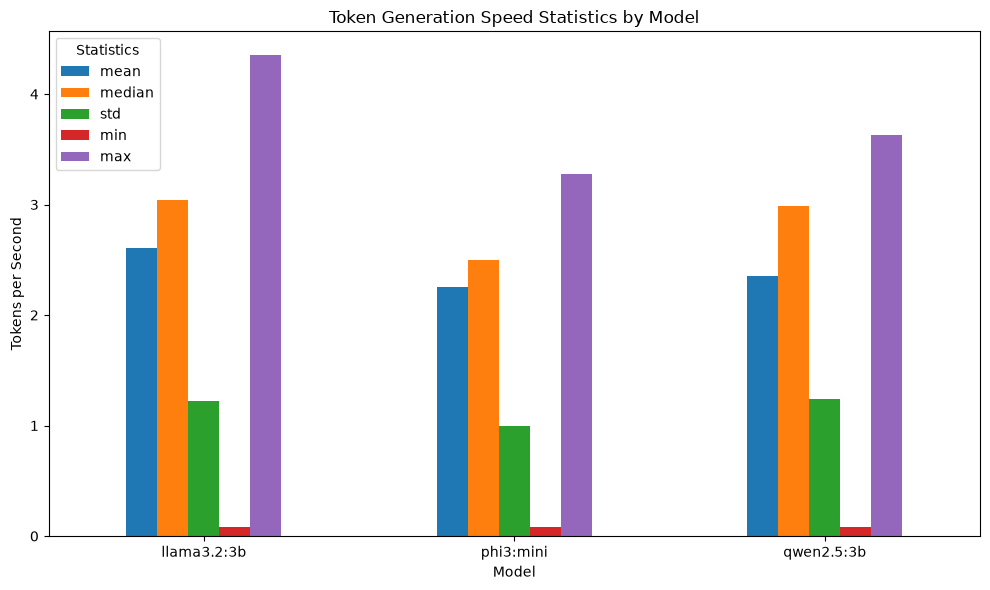

In [23]:


summary.plot(kind="bar", figsize=(10, 6))

plt.title("Token Generation Speed Statistics by Model")
plt.xlabel("Model")
plt.ylabel("Tokens per Second")
plt.xticks(rotation=0)
plt.legend(title="Statistics")
plt.tight_layout()
plt.show()

In [25]:
####ANalyze memory usage

memory_usage_summary = df.groupby("model_name")["memory_usage"].agg(
    ["mean", "median", "std","min","max"]

)

memory_usage_summary

,mean,median,std,min,max
model_name,,,,,
llama3.2:3b,9.360667,3.64,11.474715,1.57,38.06
phi3:mini,21.126667,17.21,7.638755,12.44,35.54
qwen2.5:3b,17.918000,16.52,6.181177,8.03,31.67


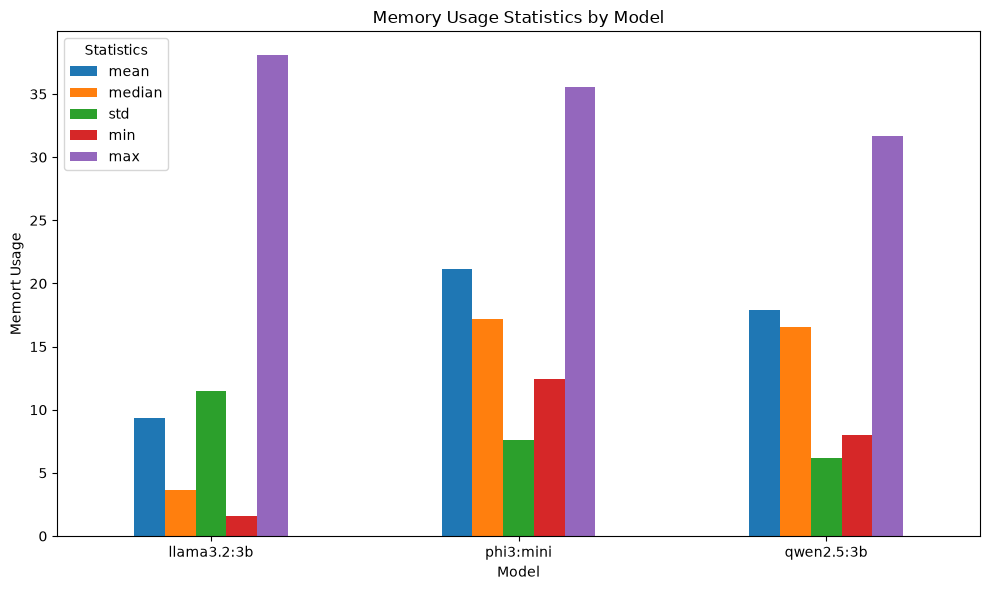

In [26]:
memory_usage_summary.plot(kind="bar", figsize=(10, 6))

plt.title("Memory Usage Statistics by Model")
plt.xlabel("Model")
plt.ylabel("Memort Usage")
plt.xticks(rotation=0)
plt.legend(title="Statistics")
plt.tight_layout()
plt.show()


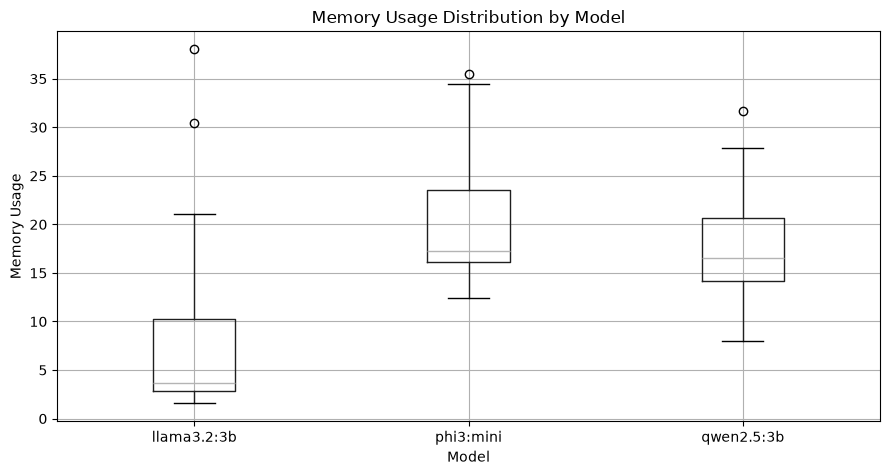

In [ ]:


df.boxplot(
    column="memory_usage",
    by="model_name",
    figsize=(9, 5)
)

plt.title("Memory Usage Distribution by Model")
plt.suptitle("")
plt.xlabel("Model")
plt.ylabel("Memory Usage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Analyze Quality

In [32]:
quality_columns = [
    "correctness",
    "relevance",
    "conciseness",
    "instruction_following",
    "quality_score"
]


quality_summary = df.groupby("model_name")[quality_columns].agg(
    ["mean", "median", "std", "min", "max"]
)

print(quality_summary)

            correctness                          relevance                   \
                   mean median       std min max      mean median       std   
model_name                                                                    
llama3.2:3b    1.133333    1.0  0.833809   0   2  1.866667    2.0  0.516398   
phi3:mini      1.066667    1.0  0.798809   0   2  2.000000    2.0  0.000000   
qwen2.5:3b     1.066667    1.0  0.703732   0   2  2.000000    2.0  0.000000   

                     ... instruction_following                           \
            min max  ...                  mean median       std min max   
model_name           ...                                                  
llama3.2:3b   0   2  ...              1.266667    2.0  0.961150   0   2   
phi3:mini     2   2  ...              1.266667    2.0  0.883715   0   2   
qwen2.5:3b    2   2  ...              1.266667    2.0  0.883715   0   2   

            quality_score                               
                 

In [33]:
quality_mean = df.groupby("model_name")[
    [
        "correctness",
        "relevance",
        "conciseness",
        "instruction_following"
    ]
].mean()

print(quality_mean)

             correctness  relevance  conciseness  instruction_following
model_name                                                             
llama3.2:3b     1.133333   1.866667     0.200000               1.266667
phi3:mini       1.066667   2.000000     0.066667               1.266667
qwen2.5:3b      1.066667   2.000000     0.133333               1.266667


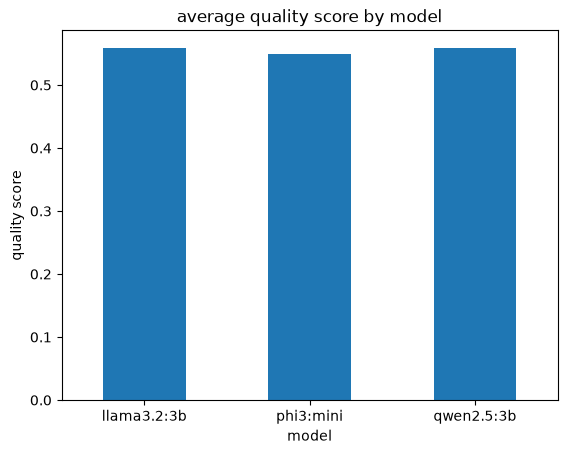

In [ ]:
#QUALITY SCORE VISUALIZATION


quality_score = df.groupby("model_name")["quality_score"].mean()

quality_score.plot(kind="bar")

plt.title("average quality score by model")
plt.xlabel("model")
plt.ylabel("quality score")
plt.xticks(rotation=0)

plt.show()

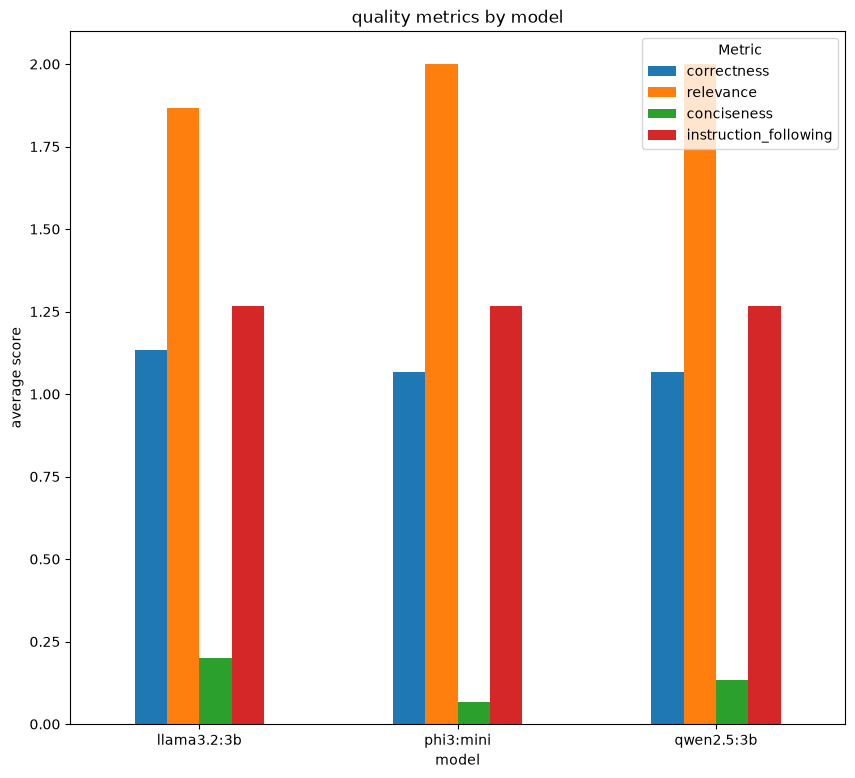

In [38]:
quality_mean.plot(kind="bar",figsize=(10,9))

plt.title("quality metrics by model")
plt.xlabel("model")
plt.ylabel("average score")
plt.xticks(rotation=0)

plt.legend(title="Metric")
plt.show()

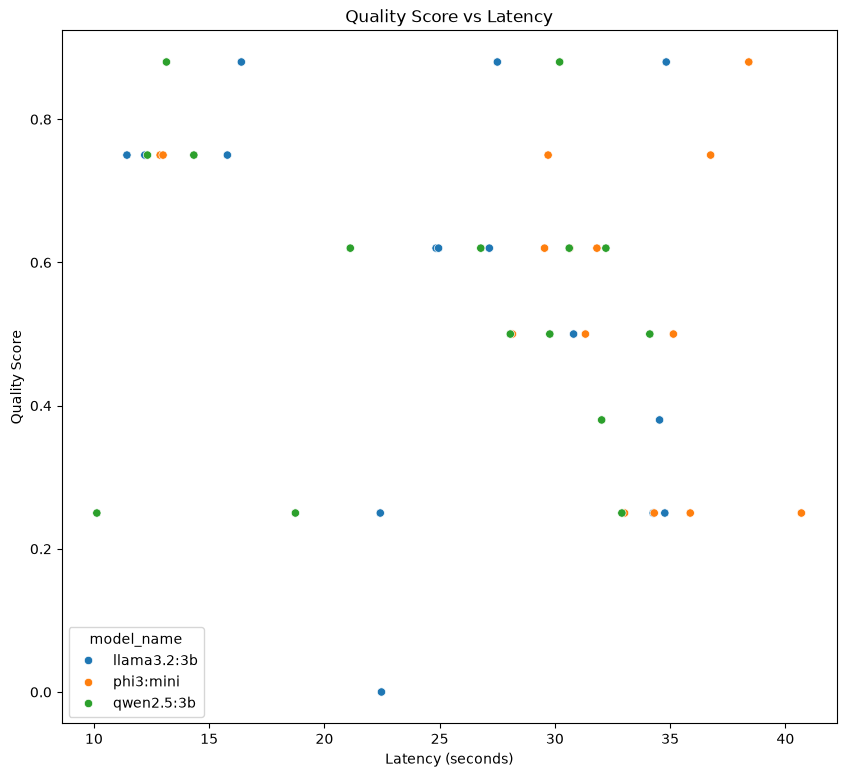

In [47]:
###  QUALITY VS SPEED
plt.figure(figsize=(10, 9))

sns.scatterplot(
    data=df,
    x="latency",
    y="quality_score",
    hue="model_name"
)

plt.title("Quality Score vs Latency")
plt.xlabel("Latency (seconds)")
plt.ylabel("Quality Score")
plt.savefig("QualityvsSpeed.png")
plt.show()



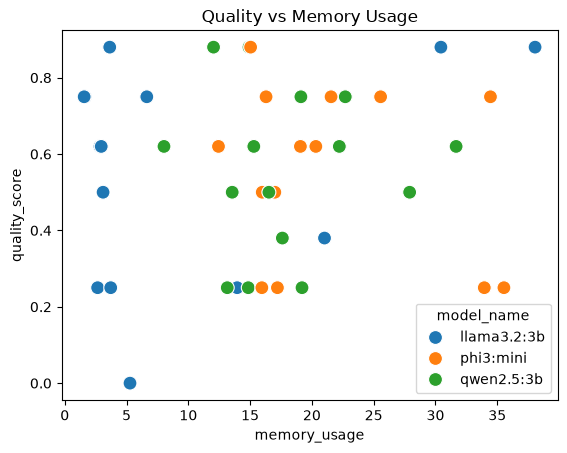

In [48]:
sns.scatterplot(
    data=df,
    x="memory_usage",
    y="quality_score",
    hue="model_name",
    s=100
)

plt.title("Quality vs Memory Usage")
plt.show()

In [51]:
summary = df.groupby("model_name").agg(
    avg_latency=("latency", "mean"),
    median_latency=("latency", "median"),
    avg_tokens_per_second=("tokens_per_second", "mean"),
    avg_memory=("memory_usage", "mean"),
    avg_correctness=("correctness", "mean"),
    avg_relevance=("relevance", "mean"),
    avg_conciseness=("conciseness", "mean"),
    avg_instruction_following=("instruction_following", "mean"),
    avg_quality=("quality_score", "mean")
)

print(summary)

             avg_latency  median_latency  avg_tokens_per_second  avg_memory  \
model_name                                                                    
llama3.2:3b    24.960367       24.953458               2.604000    9.360667   
phi3:mini      30.753081       31.822758               2.256000   21.126667   
qwen2.5:3b     24.434985       28.066118               2.353333   17.918000   

             avg_correctness  avg_relevance  avg_conciseness  \
model_name                                                     
llama3.2:3b         1.133333       1.866667         0.200000   
phi3:mini           1.066667       2.000000         0.066667   
qwen2.5:3b          1.066667       2.000000         0.133333   

             avg_instruction_following  avg_quality  
model_name                                           
llama3.2:3b                   1.266667     0.558667  
phi3:mini                     1.266667     0.549333  
qwen2.5:3b                    1.266667     0.558000  
